# ROGUE Purity Evaluation for cNMF + GSEA Pipeline

Complements `gsea_celltype_annotation.ipynb`. Two evaluations:

1. **Audit reference cell types** — compute ROGUE for each `global.cluster4` group. These are the GSEA gene sets; if any is impure, the GSEA NES scores conflate sub-states.
2. **Audit GEP-dominated groups per K** — for each K, assign each cell to its argmax-usage GEP, then compute ROGUE per group. Tracks how purity of cNMF-derived groupings evolves with K.

**Reference:** Liu et al., *Nat Commun* (2020). https://github.com/PaulingLiu/ROGUE

In [1]:
import os
import glob
import re
import numpy as np
import pandas as pd
import scanpy as sc
import anndata as ad
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import sparse
import time
from tqdm.auto import tqdm
import warnings
warnings.filterwarnings('ignore')

import rpy2.robjects as ro
from rpy2.robjects import pandas2ri, numpy2ri
from rpy2.robjects.packages import importr

CONVERTER = ro.default_converter + pandas2ri.converter + numpy2ri.converter

rogue_r = importr('ROGUE')
tibble  = importr('tibble')

## 1. Configuration

Match these to your existing notebook + point at the raw-count AnnData you fed into cNMF.

In [2]:
# --- raw-count AnnData (same one used as cNMF input) ---
ADATA_PATH = "data/hnc_myeloid_2021.h5ad" 
COUNTS_LAYER = None  # set to a layer name if counts aren't in .X; else .X is used

# --- metadata ---
METADATA_PATH = "data/hnc_myeloid_globalcluster4.csv"
BARCODE_COL   = None
CELLTYPE_COL  = "global.cluster4"
METADATA_SEP  = ","

# --- cNMF outputs (must match GSEA notebook) ---
CNMF_DIR          = "hnc_consensus_outputs_k3-35/combined_hnc_k_consensus_outputs"
CNMF_PREFIX       = "combined_hnc_k"
DENSITY_THRESHOLD = "0_01"
K_MIN, K_MAX = 3, 35

# --- ROGUE params ---
ROGUE_PLATFORM = "UMI"   # 'UMI' (=droplet) or 'full-length'
ROGUE_SPECIES  = "Human" # 'Human' or 'Mouse'
ROGUE_K        = 45      # 45 for UMI, 500 for full-length; reference factor (NOT cNMF K)
MIN_CELLS_PER_GROUP = 15

OUT_DIR = "rogue_purity_results"
os.makedirs(OUT_DIR, exist_ok=True)
print("Configuration loaded.")

Configuration loaded.


## 2. Load raw counts + metadata

In [3]:
adata = sc.read_h5ad(ADATA_PATH)
print(f"AnnData: {adata.shape}")

# Get raw counts as a dense genes × cells matrix (ROGUE expects this orientation)
X = adata.layers[COUNTS_LAYER] if COUNTS_LAYER else adata.X
if sparse.issparse(X):
    X = X.toarray()
X = X.astype(np.float64)

# Sanity check: ROGUE assumes raw counts (integer-valued, non-negative)
if not np.allclose(X, np.round(X)):
    raise ValueError("Matrix doesn't look like raw counts — check COUNTS_LAYER.")

counts_df = pd.DataFrame(X.T, index=adata.var_names, columns=adata.obs_names)
print(f"Counts matrix (genes × cells): {counts_df.shape}")

# Metadata
meta = pd.read_csv(METADATA_PATH, sep=METADATA_SEP,
                   index_col=0 if BARCODE_COL is None else None)
if BARCODE_COL is not None:
    meta = meta.set_index(BARCODE_COL)
meta.index = meta.index.astype(str)

common = counts_df.columns.intersection(meta.index)
counts_df = counts_df[common]
meta = meta.loc[common]
meta['orig.ident'] = adata.obs.loc[meta.index, 'orig.ident'].astype(str)
print(f"Aligned to {len(common)} cells")

AnnData: (26444, 23630)
Counts matrix (genes × cells): (23630, 26444)
Aligned to 26444 cells


## 3. ROGUE wrapper

Calls the R `rogue()` function on a counts matrix + per-cell labels and returns a tidy DataFrame. ROGUE returns a samples × clusters matrix (NaN where a cluster isn't present in a sample); we collapse by taking the mean across samples for a single per-cluster value.

In [4]:
def compute_rogue(counts_df, labels, samples=None,
                  platform=ROGUE_PLATFORM, species=ROGUE_SPECIES,
                  k=ROGUE_K, min_cells=MIN_CELLS_PER_GROUP,
                  verbose=True):
    """
    counts_df : DataFrame (genes × cells), raw counts
    labels    : Series indexed by cell barcode → cluster label
    samples   : Series indexed by cell barcode → sample/patient ID, or None
    Returns   : (long DataFrame [sample, cluster, ROGUE, n_cells],
                 wide DataFrame [samples × clusters])
    """
    # --- Filter tiny groups ---
    label_counts = labels.value_counts()
    keep = label_counts[label_counts >= min_cells].index
    dropped = sorted(set(label_counts.index) - set(keep))
    if dropped and verbose:
        print(f"Skipping {len(dropped)} cluster(s) below {min_cells} cells: {dropped}")

    cells = labels[labels.isin(keep)].index
    counts_sub = counts_df[cells]
    labels_sub = labels.loc[cells].astype(str)
    samples_sub = (pd.Series("all", index=cells) if samples is None
                   else samples.loc[cells].astype(str))

    # --- Build (sample, cluster) work list ---
    pairs = (pd.DataFrame({'sample': samples_sub.values, 'cluster': labels_sub.values})
               .value_counts()
               .reset_index(name='n_cells'))
    pairs = pairs[pairs['n_cells'] >= min_cells].reset_index(drop=True)

    if verbose:
        print(f"Counts: {counts_sub.shape[0]:,} genes × {counts_sub.shape[1]:,} cells")
        print(f"Computing ROGUE for {len(pairs)} (sample, cluster) pair(s)")
        for _, r in pairs.iterrows():
            print(f"  {r['sample']} / {r['cluster']}: {r['n_cells']} cells")
        print()

    # --- Push the full counts matrix to R once ---
    with CONVERTER.context():
        ro.globalenv['expr_full'] = counts_sub
    ro.r('''
        suppressMessages(library(ROGUE))
        expr_full <- as.matrix(expr_full)
    ''')

    # --- Per-(sample, cluster) loop in Python ---
    results = []
    t_total = time.time()
    iterator = tqdm(list(pairs.itertuples(index=False)),
                    total=len(pairs), disable=not verbose,
                    desc="ROGUE")

    for row in iterator:
        s, ct, n = row.sample, row.cluster, row.n_cells
        in_mask = (samples_sub == s) & (labels_sub == ct)
        sub_cells = labels_sub.index[in_mask].tolist()

        with CONVERTER.context():
            ro.globalenv['cells_keep'] = ro.StrVector(sub_cells)

        t0 = time.time()
        try:
            ro.r(f'''
                expr_mat  <- expr_full[, cells_keep, drop=FALSE]
                expr_mat  <- matr.filter(expr_mat, min.cells = 10, min.genes = 10)
                ent_res   <- SE_fun(expr_mat, span = 0.6, mt.method = "fdr")
                rogue_val <- CalculateRogue(ent_res, platform = "{platform}", k = {k})
            ''')
            with CONVERTER.context():
                rogue_val = float(ro.r('rogue_val')[0])
            ok = True
        except Exception as e:
            rogue_val = float('nan')
            ok = False
            if verbose:
                tqdm.write(f"  ✗ {s} / {ct}: FAILED — {e}")

        elapsed = time.time() - t0
        if ok and verbose:
            tqdm.write(f"  ✓ {s} / {ct:<25} ROGUE={rogue_val:.3f}  "
                       f"(n={n:>4}, {elapsed:>4.1f}s)")

        results.append({'sample': s, 'cluster': ct,
                        'ROGUE': rogue_val, 'n_cells': n})

    total = time.time() - t_total
    if verbose:
        avg = total / max(len(pairs), 1)
        print(f"\nDone in {total:.1f}s total ({avg:.1f}s/cluster avg)")

    long = pd.DataFrame(results).dropna(subset=['ROGUE']).reset_index(drop=True)
    wide = long.pivot(index='sample', columns='cluster', values='ROGUE')
    return long, wide

## 4. Application 1 — Audit the reference cell type annotations

These labels are the "gene sets" in your GSEA. Any cluster with ROGUE < ~0.9 is heterogeneous; GEPs that GSEA assigns to it may be capturing a sub-state, not the full label.

In [5]:
# Optionally split by sample/patient if you have a column for it
# samples = meta['patient_id']  # uncomment if available
samples = meta['orig.ident']

ct_long, ct_wide = compute_rogue(
    counts_df,
    labels=meta[CELLTYPE_COL],
    samples=samples,
)
ct_long.to_csv(f"{OUT_DIR}/rogue_celltype_audit.csv", index=False)

# Summarize: median ROGUE per cluster (across samples, if any)
ct_summary = (ct_long.groupby('cluster')
                     .agg(median_ROGUE=('ROGUE', 'median'),
                          mean_ROGUE  =('ROGUE', 'mean'),
                          n_samples   =('ROGUE', 'count'),
                          total_cells =('n_cells', 'sum'))
                     .sort_values('median_ROGUE'))
ct_summary

Counts: 23,630 genes × 26,444 cells
Computing ROGUE for 312 (sample, cluster) pair(s)
  GSM4138134 / Mono_CD14: 874 cells
  GSM4138116 / Mono_CD14_THBS1: 668 cells
  GSM4138126 / Mono_CD14: 618 cells
  GSM4138156 / Mono_CD14: 584 cells
  GSM4138140 / Mono_CD14: 468 cells
  GSM4138120 / Mono_CD14_ID1: 464 cells
  GSM4138132 / Mono_CD14: 443 cells
  GSM4138123 / Mac_CXCL9: 423 cells
  GSM4138137 / Mac_IL1Bint: 398 cells
  GSM4138142 / Mono_CD14: 360 cells
  GSM4138138 / Mono_CD14: 339 cells
  GSM4138136 / Mono_CD14: 329 cells
  GSM4138125 / Mac_SPP1: 319 cells
  GSM4138163 / Mono_CD14_IL1B: 313 cells
  GSM4138130 / Mono_CD14: 306 cells
  GSM4138160 / Mono_CD14_THBS1: 302 cells
  GSM4138135 / Mac_IL1Bint: 300 cells
  GSM4138162 / Mono_CD14_IL1B: 292 cells
  GSM4138165 / Mono_CD14: 285 cells
  GSM4138110 / Mono_CD14_THBS1: 255 cells
  GSM4138131 / Mono_TIL: 254 cells
  GSM4138128 / Mono_CD14: 234 cells
  GSM4138122 / Mono_CD14: 234 cells
  GSM4138167 / Mono_CD14: 234 cells
  GSM4138166 / M

ROGUE:   0%|          | 0/312 [00:00<?, ?it/s]

  ✓ GSM4138134 / Mono_CD14                 ROGUE=0.949  (n= 874,  2.5s)
  ✓ GSM4138116 / Mono_CD14_THBS1           ROGUE=0.894  (n= 668,  0.3s)
  ✓ GSM4138126 / Mono_CD14                 ROGUE=0.915  (n= 618,  0.2s)
  ✓ GSM4138156 / Mono_CD14                 ROGUE=0.892  (n= 584,  0.2s)
  ✓ GSM4138140 / Mono_CD14                 ROGUE=0.951  (n= 468,  0.2s)
  ✓ GSM4138120 / Mono_CD14_ID1             ROGUE=0.846  (n= 464,  0.2s)
  ✓ GSM4138132 / Mono_CD14                 ROGUE=0.953  (n= 443,  0.1s)
  ✓ GSM4138123 / Mac_CXCL9                 ROGUE=0.577  (n= 423,  0.3s)
  ✓ GSM4138137 / Mac_IL1Bint               ROGUE=0.625  (n= 398,  0.2s)
  ✓ GSM4138142 / Mono_CD14                 ROGUE=0.928  (n= 360,  0.1s)
  ✓ GSM4138138 / Mono_CD14                 ROGUE=0.949  (n= 339,  0.1s)
  ✓ GSM4138136 / Mono_CD14                 ROGUE=0.903  (n= 329,  0.1s)
  ✓ GSM4138125 / Mac_SPP1                  ROGUE=0.539  (n= 319,  0.2s)
  ✓ GSM4138163 / Mono_CD14_IL1B            ROGUE=0.930  (n= 313,

,median_ROGUE,mean_ROGUE,n_samples,total_cells
cluster,,,,
Mac_SPP1,0.625583,0.656306,7,532
cDC2_CD1C,0.640848,0.647154,21,886
Mac_IL1Bint,0.682749,0.685116,21,1792
Mac_CXCL9,0.720893,0.710826,13,1139
Mac_IL1B,0.748475,0.738859,10,722
mregDC_LAMP3,0.752654,0.766246,12,380
Mono_TIL,0.763075,0.766121,13,913
cDC1_CLEC9A,0.815049,0.809760,6,162
cDC2_CD33,0.870551,0.856640,36,1185


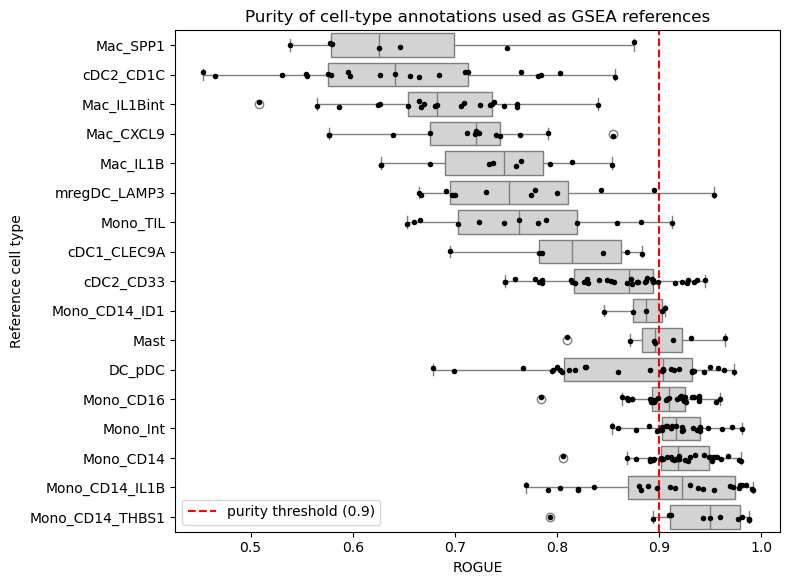

In [6]:
# Plot — flag clusters below 0.9
fig, ax = plt.subplots(figsize=(8, max(3, 0.35 * len(ct_summary))))
order = ct_summary.index
sns.boxplot(data=ct_long, y='cluster', x='ROGUE', order=order, color='lightgray', ax=ax)
sns.stripplot(data=ct_long, y='cluster', x='ROGUE', order=order, color='black', size=4, ax=ax)
ax.axvline(0.9, ls='--', color='red', label='purity threshold (0.9)')
ax.set_xlabel('ROGUE')
ax.set_ylabel('Reference cell type')
ax.set_title('Purity of cell-type annotations used as GSEA references')
ax.legend()
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/rogue_celltype_audit.png", dpi=150)
plt.show()

## 5. Application 2 — ROGUE per GEP-dominated cell group, scanned across K

For each K: load the usage matrix, assign each cell to `argmax(usage)` GEP, compute ROGUE per GEP. This tells you whether the cells most-strongly-driven by each GEP form a homogeneous population — a GEP-centric purity score that's complementary to the cell-type-centric NES from your GSEA notebook.

In [7]:
# Discover available K values (same logic as your GSEA notebook)
usage_pattern = os.path.join(
    CNMF_DIR, f"{CNMF_PREFIX}.usages.k_*.dt_{DENSITY_THRESHOLD}.consensus.txt"
)
k_values = []
for f in sorted(glob.glob(usage_pattern)):
    m = re.search(r'k_(\d+)', os.path.basename(f))
    if m:
        k = int(m.group(1))
        if K_MIN <= k <= K_MAX:
            k_values.append(k)
k_values = sorted(set(k_values))
print(f"K values: {k_values}")

K values: [3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35]


In [8]:
all_gep_rogue = {}  # k -> long DataFrame (kept in-memory for §5a/5b plots)

for k in k_values:
    usage_path = os.path.join(
        CNMF_DIR, f"{CNMF_PREFIX}.usages.k_{k}.dt_{DENSITY_THRESHOLD}.consensus.txt"
    )
    usage = pd.read_csv(usage_path, sep='\t', index_col=0)
    usage.index = usage.index.astype(str)

    cells = usage.index.intersection(counts_df.columns)
    usage = usage.loc[cells]

    # Hard-assign each cell to its dominant GEP
    gep_labels = usage.idxmax(axis=1).astype(str).rename('GEP')
    gep_labels.index.name = None

    print(f"\n{'='*60}\nK={k}: {len(cells)} cells across {usage.shape[1]} GEPs\n{'='*60}")

    long, wide = compute_rogue(
        counts_df[cells],
        labels=gep_labels,
        samples=samples.loc[cells] if samples is not None else None,
    )
    long['K'] = k

    # Save this K's results immediately
    out_path = os.path.join(OUT_DIR, f"rogue_per_gep_K{k}.csv")
    long.to_csv(out_path, index=False)
    print(f"  → saved {out_path}")

    all_gep_rogue[k] = long


K=3: 26444 cells across 3 GEPs
Counts: 23,630 genes × 26,444 cells
Computing ROGUE for 113 (sample, cluster) pair(s)
  GSM4138134 / 1: 1213 cells
  GSM4138156 / 1: 921 cells
  GSM4138126 / 1: 758 cells
  GSM4138135 / 2: 757 cells
  GSM4138116 / 1: 704 cells
  GSM4138140 / 1: 702 cells
  GSM4138142 / 1: 689 cells
  GSM4138132 / 1: 643 cells
  GSM4138136 / 1: 641 cells
  GSM4138110 / 1: 628 cells
  GSM4138120 / 1: 609 cells
  GSM4138137 / 2: 609 cells
  GSM4138123 / 2: 597 cells
  GSM4138130 / 1: 586 cells
  GSM4138138 / 1: 577 cells
  GSM4138128 / 1: 545 cells
  GSM4138122 / 1: 545 cells
  GSM4138131 / 2: 538 cells
  GSM4138139 / 2: 502 cells
  GSM4138162 / 1: 485 cells
  GSM4138160 / 1: 485 cells
  GSM4138155 / 2: 472 cells
  GSM4138166 / 1: 468 cells
  GSM4138152 / 1: 462 cells
  GSM4138146 / 1: 461 cells
  GSM4138165 / 1: 437 cells
  GSM4138163 / 1: 424 cells
  GSM4138125 / 2: 393 cells
  GSM4138154 / 1: 356 cells
  GSM4138112 / 1: 355 cells
  GSM4138114 / 1: 353 cells
  GSM4138124 

ROGUE:   0%|          | 0/113 [00:00<?, ?it/s]

  ✓ GSM4138134 / 1                         ROGUE=0.801  (n=1213,  0.5s)
  ✓ GSM4138156 / 1                         ROGUE=0.772  (n= 921,  0.4s)
  ✓ GSM4138126 / 1                         ROGUE=0.817  (n= 758,  0.3s)
  ✓ GSM4138135 / 2                         ROGUE=0.509  (n= 757,  0.4s)
  ✓ GSM4138116 / 1                         ROGUE=0.855  (n= 704,  0.3s)
  ✓ GSM4138140 / 1                         ROGUE=0.761  (n= 702,  0.3s)
  ✓ GSM4138142 / 1                         ROGUE=0.787  (n= 689,  0.4s)
  ✓ GSM4138132 / 1                         ROGUE=0.787  (n= 643,  0.3s)
  ✓ GSM4138136 / 1                         ROGUE=0.765  (n= 641,  0.3s)
  ✓ GSM4138110 / 1                         ROGUE=0.766  (n= 628,  0.3s)
  ✓ GSM4138120 / 1                         ROGUE=0.760  (n= 609,  0.3s)
  ✓ GSM4138137 / 2                         ROGUE=0.580  (n= 609,  0.4s)
  ✓ GSM4138123 / 2                         ROGUE=0.486  (n= 597,  0.4s)
  ✓ GSM4138130 / 1                         ROGUE=0.750  (n= 586,

ROGUE:   0%|          | 0/126 [00:00<?, ?it/s]

  ✓ GSM4138134 / 1                         ROGUE=0.801  (n=1213,  2.7s)
  ✓ GSM4138156 / 1                         ROGUE=0.776  (n= 919,  0.3s)
  ✓ GSM4138126 / 1                         ROGUE=0.817  (n= 758,  0.3s)
  ✓ GSM4138116 / 1                         ROGUE=0.859  (n= 703,  0.3s)
  ✓ GSM4138140 / 1                         ROGUE=0.768  (n= 700,  0.3s)
  ✓ GSM4138142 / 1                         ROGUE=0.787  (n= 689,  0.3s)
  ✓ GSM4138132 / 1                         ROGUE=0.787  (n= 643,  0.2s)
  ✓ GSM4138136 / 1                         ROGUE=0.765  (n= 641,  0.3s)
  ✓ GSM4138110 / 1                         ROGUE=0.766  (n= 628,  0.3s)
  ✓ GSM4138120 / 1                         ROGUE=0.760  (n= 609,  0.3s)
  ✓ GSM4138130 / 1                         ROGUE=0.747  (n= 585,  0.3s)
  ✓ GSM4138138 / 1                         ROGUE=0.745  (n= 576,  0.2s)
  ✓ GSM4138123 / 2                         ROGUE=0.500  (n= 562,  0.4s)
  ✓ GSM4138122 / 1                         ROGUE=0.748  (n= 543,

...

ROGUE:   0%|          | 0/226 [00:00<?, ?it/s]

  ✓ GSM4138134 / 1                         ROGUE=0.923  (n= 809,  0.8s)
  ✓ GSM4138116 / 1                         ROGUE=0.897  (n= 680,  0.3s)
  ✓ GSM4138126 / 1                         ROGUE=0.887  (n= 670,  0.3s)
  ✓ GSM4138156 / 1                         ROGUE=0.834  (n= 651,  0.3s)
  ✓ GSM4138120 / 1                         ROGUE=0.820  (n= 511,  0.3s)
  ✓ GSM4138142 / 1                         ROGUE=0.888  (n= 484,  0.2s)
  ✓ GSM4138110 / 1                         ROGUE=0.897  (n= 460,  0.2s)
  ✓ GSM4138140 / 1                         ROGUE=0.923  (n= 454,  0.2s)
  ✓ GSM4138132 / 1                         ROGUE=0.914  (n= 419,  0.2s)
  ✓ GSM4138160 / 1                         ROGUE=0.866  (n= 413,  0.2s)
  ✓ GSM4138134 / 2                         ROGUE=0.813  (n= 402,  0.2s)
  ✓ GSM4138123 / 4                         ROGUE=0.584  (n= 396,  0.3s)
  ✓ GSM4138136 / 1                         ROGUE=0.861  (n= 384,  0.1s)
  ✓ GSM4138138 / 1                         ROGUE=0.929  (n= 371,

ROGUE:   0%|          | 0/238 [00:00<?, ?it/s]

  ✓ GSM4138134 / 1                         ROGUE=0.925  (n= 807,  0.7s)
  ✓ GSM4138116 / 1                         ROGUE=0.898  (n= 679,  0.3s)
  ✓ GSM4138126 / 1                         ROGUE=0.887  (n= 664,  0.2s)
  ✓ GSM4138156 / 1                         ROGUE=0.831  (n= 654,  0.2s)
  ✓ GSM4138120 / 1                         ROGUE=0.820  (n= 511,  0.2s)
  ✓ GSM4138142 / 1                         ROGUE=0.886  (n= 479,  0.2s)
  ✓ GSM4138110 / 1                         ROGUE=0.897  (n= 460,  0.2s)
  ✓ GSM4138140 / 1                         ROGUE=0.910  (n= 453,  0.2s)
  ✓ GSM4138132 / 1                         ROGUE=0.913  (n= 417,  0.2s)
  ✓ GSM4138160 / 1                         ROGUE=0.866  (n= 412,  0.2s)
  ✓ GSM4138134 / 2                         ROGUE=0.816  (n= 404,  0.2s)
  ✓ GSM4138123 / 4                         ROGUE=0.586  (n= 398,  0.3s)
  ✓ GSM4138136 / 1                         ROGUE=0.853  (n= 384,  0.1s)
  ✓ GSM4138138 / 1                         ROGUE=0.930  (n= 371,

KeyboardInterrupt: 

### 5a. Mean ROGUE vs K — a purity-based aid for K selection

Read this together with your hierarchical-tree analysis. Where ROGUE plateaus, you've stopped resolving meaningfully purer programs; further K just shaves cells off existing GEPs.

In [ ]:
k_summary = (gep_rogue_long
             .groupby('K')
             .agg(mean_ROGUE  =('ROGUE', 'mean'),
                  median_ROGUE=('ROGUE', 'median'),
                  min_ROGUE   =('ROGUE', 'min'),
                  frac_pure   =('ROGUE', lambda x: (x >= 0.9).mean()))
             .reset_index())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(k_summary['K'], k_summary['mean_ROGUE'], marker='o', label='mean')
axes[0].plot(k_summary['K'], k_summary['median_ROGUE'], marker='s', label='median')
axes[0].axhline(0.9, ls='--', color='red', alpha=0.5)
axes[0].set(xlabel='cNMF K', ylabel='ROGUE across GEPs',
            title='Average GEP-group purity vs K')
axes[0].legend()

axes[1].plot(k_summary['K'], k_summary['frac_pure'], marker='o', color='green')
axes[1].set(xlabel='cNMF K', ylabel='Fraction of GEPs with ROGUE ≥ 0.9',
            title='Share of GEPs that are "pure"', ylim=(0, 1.05))
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/rogue_vs_K.png", dpi=150)
plt.show()
k_summary

### 5b. Per-GEP ROGUE at a chosen K, alongside its top GSEA cell-type assignment

This is the join with your existing notebook: each GEP gets both an NES-based cell-type label *and* a purity score. The most defensible GEPs are those with both **a strong NES for one cell type** *and* **ROGUE ≥ 0.9** on the cells that dominantly express them.

In [ ]:
K_TO_INSPECT = 5  # match K_TO_PLOT in your GSEA notebook

# ROGUE side
gep_at_k = (gep_rogue_long.query('K == @K_TO_INSPECT')
                          .groupby('cluster')['ROGUE']
                          .median()
                          .rename('ROGUE'))

# GSEA side — load the NES CSV your existing notebook produced
GSEA_NES_DIR = "combined-hnc_k3-35_gsea_celltype_results"  # update if different
nes_path = os.path.join(GSEA_NES_DIR, f"NES_k{K_TO_INSPECT}.csv")
if os.path.exists(nes_path):
    nes = pd.read_csv(nes_path, index_col=0)
    top_assignment = pd.DataFrame({
        'top_celltype': nes.idxmax(axis=1),
        'top_NES'     : nes.max(axis=1),
    })
    joined = top_assignment.join(gep_at_k, how='outer')
    joined['pure_and_assigned'] = (joined['ROGUE'] >= 0.9) & (joined['top_NES'] >= 1.5)
    print(joined.sort_values('ROGUE', ascending=False))
    joined.to_csv(f"{OUT_DIR}/gep_assignment_with_purity_K{K_TO_INSPECT}.csv")
else:
    print(f"NES file not found at {nes_path} — update GSEA_NES_DIR.")
    joined = None

In [ ]:
# Scatter: x = top NES, y = ROGUE, label = top cell type. Top-right quadrant = trustworthy GEPs.
if joined is not None and joined['ROGUE'].notna().any():
    fig, ax = plt.subplots(figsize=(8, 6))
    ax.scatter(joined['top_NES'], joined['ROGUE'],
               c=['green' if p else 'gray' for p in joined['pure_and_assigned']],
               s=80, edgecolor='black')
    for gep, row in joined.iterrows():
        if pd.notna(row['ROGUE']):
            ax.annotate(f"{gep}\n{row['top_celltype']}",
                        (row['top_NES'], row['ROGUE']),
                        fontsize=8, alpha=0.8,
                        xytext=(4, 4), textcoords='offset points')
    ax.axhline(0.9, ls='--', color='red', alpha=0.5)
    ax.axvline(1.5, ls='--', color='red', alpha=0.5)
    ax.set(xlabel='Top GSEA NES (cell type assignment strength)',
           ylabel='ROGUE (purity of GEP-dominated cells)',
           title=f'GEP quality at K={K_TO_INSPECT}: assignment × purity')
    plt.tight_layout()
    plt.savefig(f"{OUT_DIR}/gep_quality_K{K_TO_INSPECT}.png", dpi=150)
    plt.show()

## 6. Interpretation cheatsheet

| ROGUE | Top NES | Reading |
|---|---|---|
| ≥ 0.9 | high (≥ 1.5) | Clean GEP — pure population, mapped confidently to one reference cell type. Use this. |
| ≥ 0.9 | low | GEP is pure but doesn't match any reference type — possibly a state/program orthogonal to your `global.cluster4` labels (e.g., cell cycle, IFN response). Worth investigating with gene-spectra inspection. |
| < 0.9 | high | The GEP loosely tracks a cell type but its top-loaded cells are heterogeneous — could be a cell type that itself is impure in `global.cluster4` (cross-check with §4) or a GEP capturing more than one population. |
| < 0.9 | low | Likely an artifact / overcomplete GEP at this K. Decreases at higher K may not be meaningful. |

**On the K plateau:** picking the smallest K where mean GEP ROGUE crosses ~0.9 (and the fraction of pure GEPs stops climbing) gives a defensible upper bound. Below it you're still merging biology; above it you're splitting noise.